# Compare Baseline CNN vs Residual CNN

This notebook loads the same noisy image, runs both trained denoising models, saves their outputs, and compares them visually, architecturally, and mathematically.

In [1]:
from pathlib import Path
import math
import sys

import matplotlib.pyplot as plt
import torch
from PIL import Image
from skimage.metrics import peak_signal_noise_ratio, structural_similarity
import torchvision.transforms as T


def find_repo_root() -> Path:
    candidates = [Path.cwd(), *Path.cwd().parents]
    for candidate in candidates:
        if (candidate / "models").exists() and (candidate / "training").exists():
            return candidate
    raise FileNotFoundError("Could not locate the repository root from the current notebook directory.")


REPO_ROOT = find_repo_root()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from models.baseline_cnn import BaselineCNN
from models.residual_cnn import ResidualCNN

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {DEVICE}")
print(f"Repository root: {REPO_ROOT}")

Using device: cpu
Repository root: C:\repository\SP25-690-Turakapalli


In [2]:
def load_image(path: Path, image_size: int = 128) -> torch.Tensor:
    image = Image.open(path).convert("RGB")
    transform = T.Compose([
        T.Resize((image_size, image_size)),
        T.ToTensor(),
    ])
    return transform(image).unsqueeze(0)


def tensor_to_image(tensor: torch.Tensor) -> Image.Image:
    tensor = tensor.detach().cpu().clamp(0, 1).squeeze(0)
    return T.ToPILImage()(tensor)


def save_tensor_image(tensor: torch.Tensor, path: Path) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    tensor_to_image(tensor).save(path)


def load_model(model_name: str, checkpoint_path: Path) -> torch.nn.Module:
    if model_name == "baseline":
        model = BaselineCNN()
    elif model_name == "residual":
        model = ResidualCNN()
    else:
        raise ValueError(f"Unsupported model: {model_name}")

    state = torch.load(checkpoint_path, map_location=DEVICE)
    model.load_state_dict(state.get("model_state", state))
    model.to(DEVICE)
    model.eval()
    return model


def run_model(model_name: str, checkpoint_path: Path, noisy_tensor: torch.Tensor) -> torch.Tensor:
    model = load_model(model_name, checkpoint_path)
    with torch.no_grad():
        return model(noisy_tensor.to(DEVICE)).cpu()


def count_parameters(model: torch.nn.Module) -> int:
    return sum(param.numel() for param in model.parameters())


def describe_model(model_name: str, model: torch.nn.Module) -> dict:
    return {
        "model": model_name,
        "parameters": count_parameters(model),
        "skip_connection": "yes" if model_name == "residual" else "no",
        "core_behavior": "predict clean image directly" if model_name == "baseline" else "learn residual and add it to input",
    }


def to_numpy_image(tensor: torch.Tensor):
    return tensor.detach().cpu().clamp(0, 1).squeeze(0).permute(1, 2, 0).numpy()


def image_metrics(reference: torch.Tensor, candidate: torch.Tensor) -> dict:
    reference_np = to_numpy_image(reference)
    candidate_np = to_numpy_image(candidate)
    mse = torch.mean((reference - candidate) ** 2).item()
    mae = torch.mean(torch.abs(reference - candidate)).item()
    psnr = peak_signal_noise_ratio(reference_np, candidate_np, data_range=1.0)
    ssim = structural_similarity(reference_np, candidate_np, channel_axis=2, data_range=1.0)
    return {
        "mse": mse,
        "mae": mae,
        "psnr": psnr,
        "ssim": ssim,
    }


def print_dict_table(title: str, rows: list[dict]) -> None:
    print(title)
    for row in rows:
        print(row)

In [3]:
IMAGE_SIZE = 128
NOISY_IMAGE_PATH = REPO_ROOT / "data" / "noisy_test.png"
BASELINE_CHECKPOINT = REPO_ROOT / "training" / "baseline_cifar10_noise25.pth"
RESIDUAL_CHECKPOINT = REPO_ROOT / "training" / "residual_cifar10_noise25.pth"
BASELINE_OUTPUT = REPO_ROOT / "results" / "baseline_denoised.png"
RESIDUAL_OUTPUT = REPO_ROOT / "results" / "residual_denoised.png"

required_paths = [NOISY_IMAGE_PATH, BASELINE_CHECKPOINT, RESIDUAL_CHECKPOINT]
missing_paths = [str(path) for path in required_paths if not path.exists()]
if missing_paths:
    raise FileNotFoundError("Missing required files:\n" + "\n".join(missing_paths))

noisy_tensor = load_image(NOISY_IMAGE_PATH, IMAGE_SIZE)
baseline_model = load_model("baseline", BASELINE_CHECKPOINT)
residual_model = load_model("residual", RESIDUAL_CHECKPOINT)
baseline_output = run_model("baseline", BASELINE_CHECKPOINT, noisy_tensor)
residual_output = run_model("residual", RESIDUAL_CHECKPOINT, noisy_tensor)

save_tensor_image(baseline_output, BASELINE_OUTPUT)
save_tensor_image(residual_output, RESIDUAL_OUTPUT)

print(f"Saved baseline output to: {BASELINE_OUTPUT}")
print(f"Saved residual output to: {RESIDUAL_OUTPUT}")

Saved baseline output to: C:\repository\SP25-690-Turakapalli\results\baseline_denoised.png
Saved residual output to: C:\repository\SP25-690-Turakapalli\results\residual_denoised.png


## General Neural Network Comparison

This section compares the two networks by architecture and modeling strategy, not just by the images they produce.

In [4]:
model_comparison = [
    describe_model("baseline", baseline_model),
    describe_model("residual", residual_model),
]

print_dict_table("Model comparison", model_comparison)

print("\nInterpretation")
print("- Baseline CNN maps the noisy image directly to a denoised image.")
print("- Residual CNN predicts a correction term and adds it back to the input.")
print("- Residual learning often helps preserve structure because the network focuses on what should change rather than rebuilding the full image from scratch.")

Model comparison
{'model': 'baseline', 'parameters': 40451, 'skip_connection': 'no', 'core_behavior': 'predict clean image directly'}
{'model': 'residual', 'parameters': 40451, 'skip_connection': 'yes', 'core_behavior': 'learn residual and add it to input'}

Interpretation
- Baseline CNN maps the noisy image directly to a denoised image.
- Residual CNN predicts a correction term and adds it back to the input.
- Residual learning often helps preserve structure because the network focuses on what should change rather than rebuilding the full image from scratch.


## Mathematical Image Comparison

Because this notebook uses a noisy input without a clean ground-truth image, the metrics below are reference-relative comparisons. They measure how far each output is from the noisy input and how far the two model outputs are from each other.

In [5]:
baseline_vs_noisy = image_metrics(noisy_tensor, baseline_output)
residual_vs_noisy = image_metrics(noisy_tensor, residual_output)
baseline_vs_residual = image_metrics(baseline_output, residual_output)

metric_rows = [
    {"comparison": "baseline vs noisy", **baseline_vs_noisy},
    {"comparison": "residual vs noisy", **residual_vs_noisy},
    {"comparison": "baseline vs residual", **baseline_vs_residual},
]

print_dict_table("Image metric comparison", metric_rows)

print("\nMetric notes")
print("- Lower MSE and MAE mean two images are numerically closer.")
print("- Higher PSNR usually indicates less distortion between the compared images.")
print("- Higher SSIM indicates greater structural similarity.")

Image metric comparison
{'comparison': 'baseline vs noisy', 'mse': 0.008352778851985931, 'mae': 0.07294046878814697, 'psnr': np.float64(20.78169031040641), 'ssim': np.float32(0.21562676)}
{'comparison': 'residual vs noisy', 'mse': 0.00867320504039526, 'mae': 0.07441531866788864, 'psnr': np.float64(20.61820365596994), 'ssim': np.float32(0.18029843)}
{'comparison': 'baseline vs residual', 'mse': 4.99968409712892e-05, 'mae': 0.005569441709667444, 'psnr': np.float64(43.01057412257013), 'ssim': np.float32(0.9743685)}

Metric notes
- Lower MSE and MAE mean two images are numerically closer.
- Higher PSNR usually indicates less distortion between the compared images.
- Higher SSIM indicates greater structural similarity.


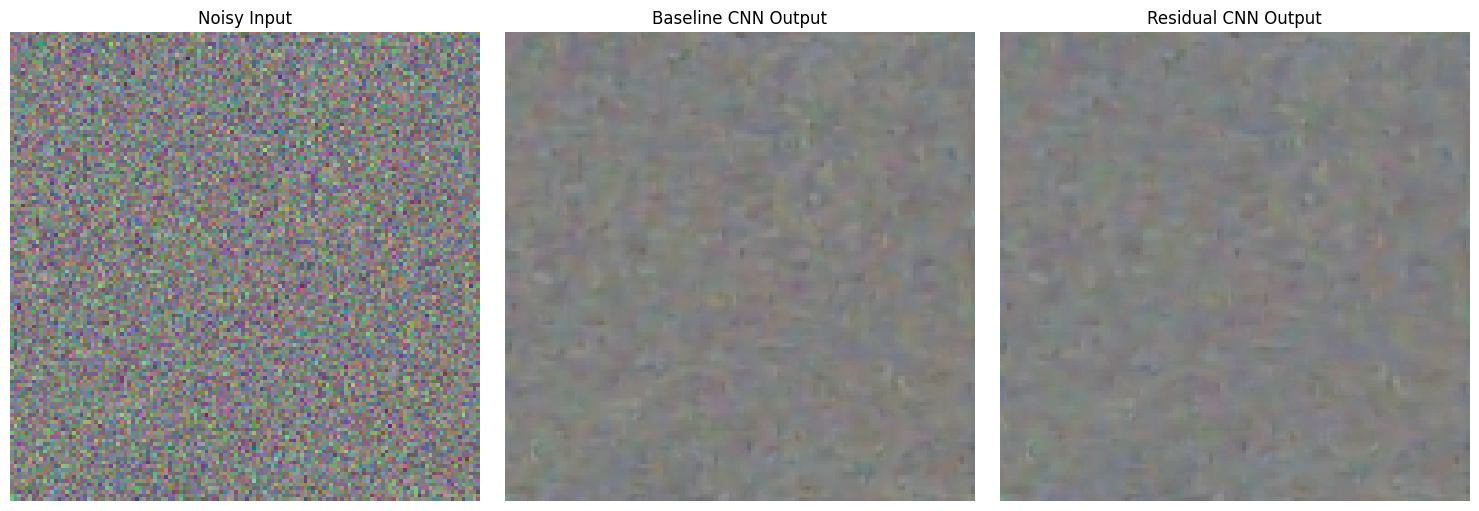

In [6]:
comparison_images = [
    ("Noisy Input", tensor_to_image(noisy_tensor)),
    ("Baseline CNN Output", tensor_to_image(baseline_output)),
    ("Residual CNN Output", tensor_to_image(residual_output)),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for axis, (title, image) in zip(axes, comparison_images):
    axis.imshow(image)
    axis.set_title(title)
    axis.axis("off")

plt.tight_layout()
plt.show()